# DOA Performance Evaluation with Multiple Algorithms

This notebook demonstrates the use of our custom DOA performance evaluator and plotting tools to analyze the performance of multiple DOA algorithms under different conditions.

We will evaluate the following DOA algorithms:
- Root-MUSIC
- MUSIC
- ESPRIT
- MVDR
- Bartlett

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import doatools.model as model
import doatools.estimation as estimation
import doatools.performance as perf
import doatools.plotting.plot_performance as plt_tools
from tqdm import tqdm
%matplotlib inline

# 设置全局字体和大小
plt.rcParams.update({
    'font.family': 'Times New Roman',
    'font.size': 18,
    'axes.titlesize': 18,
    'axes.labelsize': 18,
    'legend.fontsize': 18,
    'legend.loc': 'upper right',
    'legend.title_fontsize': 18,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18
})

# 自定义MUSIC算法的颜色和标记
plt_tools.set_doa_method_style('MUSIC', color='darkorange', marker='s')

# 获取当前配置，查看修改效果
print('当前MUSIC算法样式:', plt_tools.get_doa_method_style('MUSIC'))

当前MUSIC算法样式: ('darkorange', 's')


## 1. Simulation Parameters Setup

In [2]:
# Basic parameters
wavelength = 1.0  # Normalized wavelength
d0 = wavelength / 2  # Inter-element spacing
n_sources = 4  # Number of sources
source_angles = np.array(np.deg2rad([-40.0, 0.0, 30.0, 60.0]))  # Source angles in radians

# Array design
n_elements = 10
array = model.UniformLinearArray(n_elements, d0)

# Source placement
sources = model.FarField1DSourcePlacement(source_angles)

# Define estimators
estimators = {
    'RootMUSIC': estimation.RootMUSIC1D(wavelength),
    'MUSIC': estimation.MUSIC(array, wavelength, estimation.FarField1DSearchGrid(
        start=-np.pi/2, stop=np.pi/2, size=1000, unit='rad'
    )),
    'ESPRIT': estimation.Esprit1D(wavelength),
    'MVDR': estimation.MVDRBeamformer(array, wavelength, estimation.FarField1DSearchGrid(
        start=-np.pi/2, stop=np.pi/2, size=1000, unit='rad'
    )),
    'Bartlett': estimation.BartlettBeamformer(array, wavelength, estimation.FarField1DSearchGrid(
        start=-np.pi/2, stop=np.pi/2, size=1000, unit='rad'
    ))
}

# Monte Carlo simulation parameters
n_monte_carlo = 100

## 2. Performance vs. SNR

In [3]:
# Parameters for SNR test
snr_values = np.linspace(-20, 20, 11)  # SNR values from -20 dB to 20 dB
n_snapshots_snr = 256  # Number of snapshots for SNR test

print(f'Running SNR performance test with {len(snr_values)} SNR points...')

# Initialize results storage
snr_results = {alg: {'mse': [], 'bias': []} for alg in estimators.keys()}
crb_snr_values = []

# Run simulation for each SNR
for snr in tqdm(snr_values):
    # Run performance evaluation
    result = perf.evaluate_performance(
        array=array,
        sources=sources,
        snr=snr,
        n_snapshots=n_snapshots_snr,
        n_monte_carlo=n_monte_carlo,
        estimators=estimators,
        crb_types=['sto'],
        metrics=['mse', 'bias']
    )
    
    # Store results
    for alg in estimators.keys():
        snr_results[alg]['mse'].append(result.estimator_results[alg]['mse']) 
        snr_results[alg]['bias'].append(result.estimator_results[alg]['bias']) 
    
    # Store CRB values
    crb_snr_values.append(result.crb_values['sto'])

# Convert lists to numpy arrays for easier plotting
for alg in snr_results.keys():
    snr_results[alg]['mse'] = np.array(snr_results[alg]['mse']) 
    snr_results[alg]['bias'] = np.array(snr_results[alg]['bias']) 

crb_snr_values = np.array(crb_snr_values)
print('SNR performance test completed!')

Running SNR performance test with 11 SNR points...


100%|██████████| 11/11 [00:02<00:00,  4.07it/s]

SNR performance test completed!


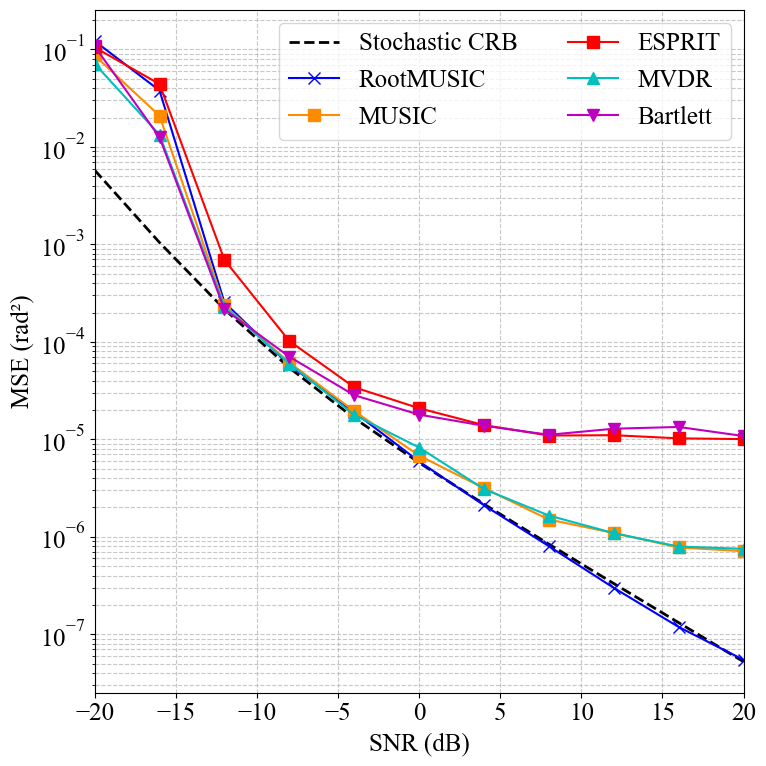

In [4]:
# Plot MSE vs SNR using our plotting tool
fig, ax = plt.subplots(figsize=(8, 8))  # 使用正方形比例
plt_tools.plot_metric_vs_parameter(
    parameter_values=snr_values,
    results={alg: snr_results[alg]['mse'] for alg in snr_results.keys()},
    parameter_name='SNR',
    metric_name='MSE',
    parameter_unit='dB',
    metric_unit='rad²',
    show_crb=True,
    crb_values=crb_snr_values,
    crb_label='Stochastic CRB',
    ax=ax
    )
plt.tight_layout()
plt.show()

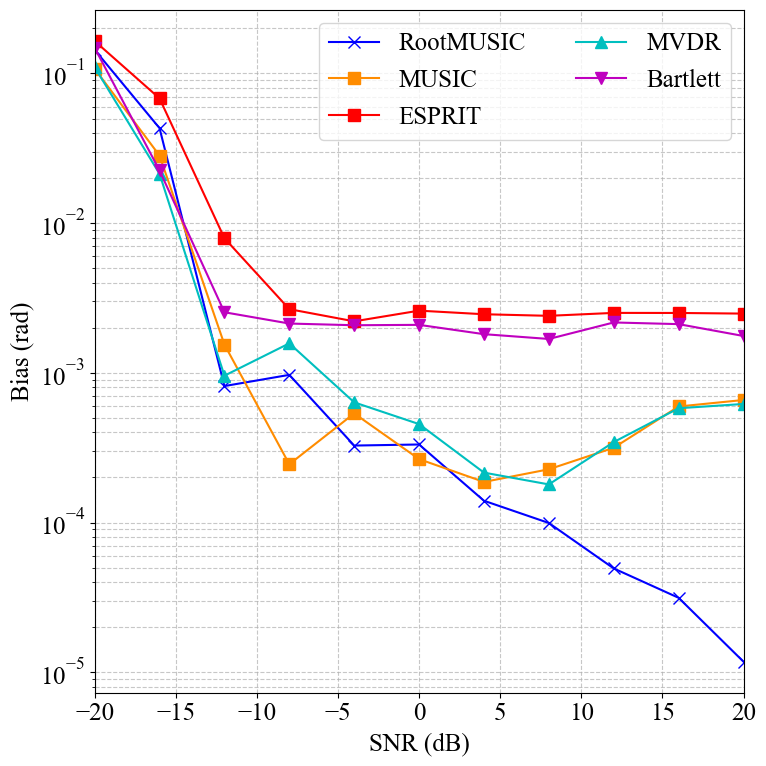

In [5]:
# Plot Bias vs SNR using our plotting tool
fig, ax = plt.subplots(figsize=(8, 8))  # 使用正方形比例
plt_tools.plot_metric_vs_parameter(
    parameter_values=snr_values,
    results={alg: snr_results[alg]['bias'] for alg in snr_results.keys()},
    parameter_name='SNR',
    metric_name='Bias',
    parameter_unit='dB',
    metric_unit='rad',
    ax=ax
    )
plt.tight_layout()
plt.show()

## 3. Performance vs. Number of Snapshots

In [6]:
# Parameters for snapshot test
snapshot_values = np.array([10, 20, 50, 100, 200, 500])  # Number of snapshots
snr_snapshot = 0.0  # SNR in dB for snapshot test

print(f'Running snapshot performance test with {len(snapshot_values)} snapshot points...')

# Initialize results storage
snapshot_results = {alg: {'mse': [], 'bias': []} for alg in estimators.keys()}
crb_snapshot_values = []

# Run simulation for each snapshot count
for n_snap in tqdm(snapshot_values):
    # Run performance evaluation
    result = perf.evaluate_performance(
        array=array,
        sources=sources,
        snr=snr_snapshot,
        n_snapshots=n_snap,
        n_monte_carlo=n_monte_carlo,
        estimators=estimators,
        crb_types=['sto'],
        metrics=['mse', 'bias']
    )
    
    # Store results
    for alg in estimators.keys():
        snapshot_results[alg]['mse'].append(result.estimator_results[alg]['mse']) 
        snapshot_results[alg]['bias'].append(result.estimator_results[alg]['bias']) 
    
    # Store CRB values
    crb_snapshot_values.append(result.crb_values['sto'])

# Convert lists to numpy arrays for easier plotting
for alg in snapshot_results.keys():
    snapshot_results[alg]['mse'] = np.array(snapshot_results[alg]['mse']) 
    snapshot_results[alg]['bias'] = np.array(snapshot_results[alg]['bias']) 

crb_snapshot_values = np.array(crb_snapshot_values)
print('Snapshot performance test completed!')

Running snapshot performance test with 6 snapshot points...


100%|██████████| 6/6 [00:01<00:00,  4.74it/s]

Snapshot performance test completed!


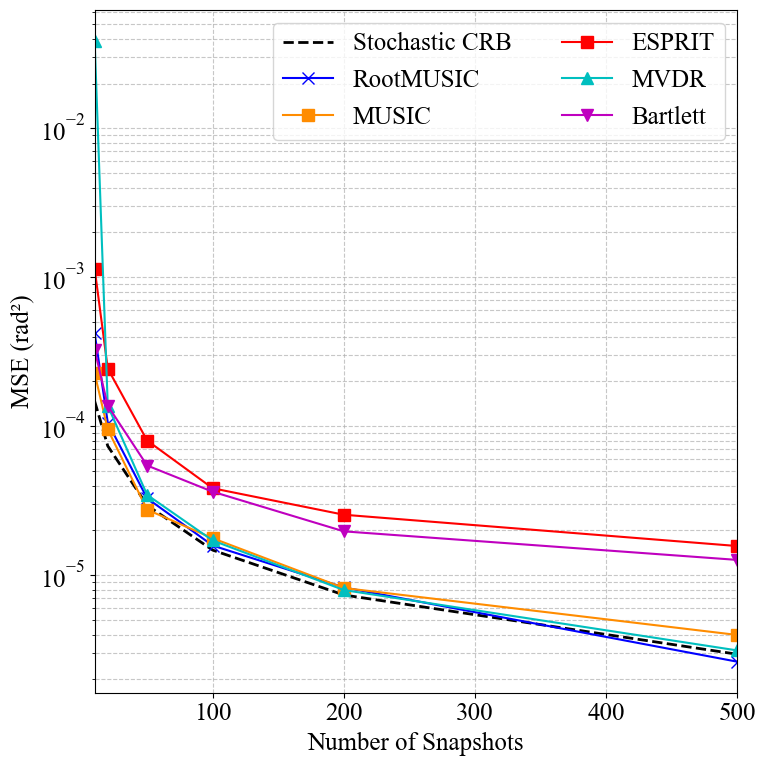

In [7]:
# Plot MSE vs Number of Snapshots using our plotting tool
fig, ax = plt.subplots(figsize=(8, 8))  # 使用正方形比例
plt_tools.plot_metric_vs_parameter(
    parameter_values=snapshot_values,
    results={alg: snapshot_results[alg]['mse'] for alg in snapshot_results.keys()},
    parameter_name='Number of Snapshots',
    metric_name='MSE',
    metric_unit='rad²',
    show_crb=True,
    crb_values=crb_snapshot_values,
    crb_label='Stochastic CRB',
    ax=ax
    )
plt.tight_layout()
plt.show()

## 4. Resolution Performance vs. Angular Separation

In [8]:
# Parameters for resolution test
delta_thetas_deg = np.linspace(1.0, 10.0, 10)  # Angular separations in degrees
delta_thetas_rad = np.deg2rad(delta_thetas_deg)  # Convert to radians
snr_resolution = 10.0  # SNR in dB for resolution test
n_snapshots_resolution = 200  # Number of snapshots for resolution test

print(f'Running resolution performance test with {len(delta_thetas_deg)} angular separations...')

# Initialize results storage
resolution_results = {alg: {'mse': []} for alg in estimators.keys()}

# Run simulation for each angular separation
for delta_theta in tqdm(delta_thetas_rad):
    # Create sources with current separation
    resolved_sources = model.FarField1DSourcePlacement(
        [-delta_theta/2, delta_theta/2]
    )
    
    # Run performance evaluation
    result = perf.evaluate_performance(
        array=array,
        sources=resolved_sources,
        snr=snr_resolution,
        n_snapshots=n_snapshots_resolution,
        n_monte_carlo=n_monte_carlo,
        estimators=estimators,
        crb_types=['sto'],
        metrics=['mse']
    )
    
    # Store results
    for alg in estimators.keys():
        resolution_results[alg]['mse'].append(result.estimator_results[alg]['mse']) 

# Convert lists to numpy arrays for easier plotting
for alg in resolution_results.keys():
    resolution_results[alg]['mse'] = np.array(resolution_results[alg]['mse']) 

print('Resolution performance test completed!')

Running resolution performance test with 10 angular separations...


100%|██████████| 10/10 [00:02<00:00,  4.62it/s]

Resolution performance test completed!


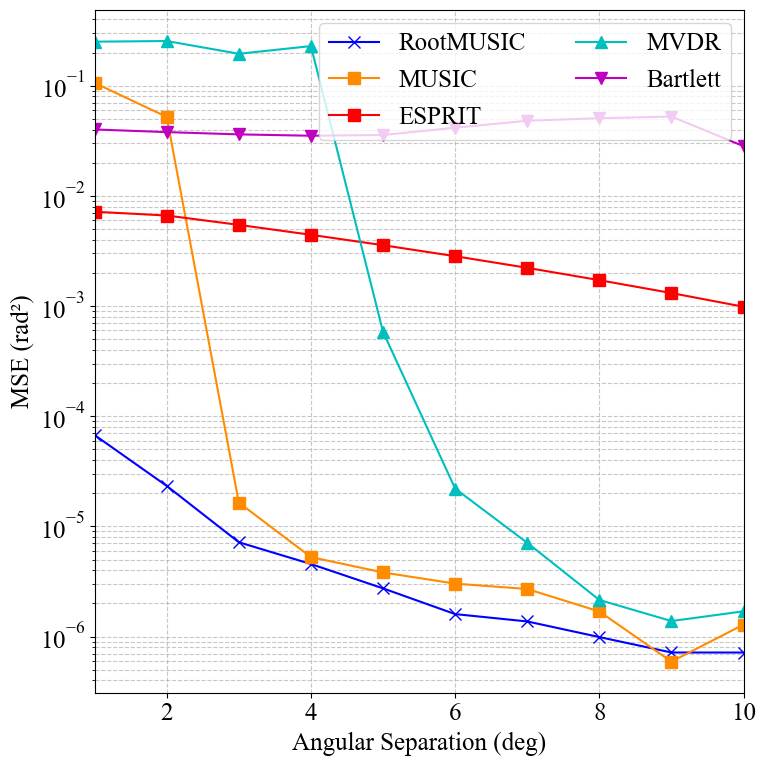

In [9]:
# Plot MSE vs Angular Separation using our plotting tool
fig, ax = plt.subplots(figsize=(8, 8))  # 使用正方形比例
plt_tools.plot_metric_vs_parameter(
    parameter_values=delta_thetas_deg,
    results={alg: resolution_results[alg]['mse'] for alg in resolution_results.keys()},
    parameter_name='Angular Separation',
    metric_name='MSE',
    parameter_unit='deg',
    metric_unit='rad²',
    show_crb=False,
    ax=ax
    )
plt.tight_layout()
plt.show()

## 5. 各个算法的不同Scatter 分布

In [10]:
# Let's generate scatter plots for all algorithms
# We'll use SNR=0 dB with 100 snapshots

print('Generating scatter plots for all algorithms...')

sample_snr = 0.0  # SNR in dB
sample_n_snapshots = 100  # Number of snapshots
sample_n_monte_carlo = 200  # Number of Monte Carlo runs for sample generation

# Run performance evaluation with save_sample_estimates=True
sample_result = perf.evaluate_performance(
    array=array,
    sources=sources,
    snr=sample_snr,
    n_snapshots=sample_n_snapshots,
    n_monte_carlo=sample_n_monte_carlo,
    estimators=estimators,
    crb_types=['sto'],
    metrics=['mse', 'bias'],
    save_sample_estimates=True
)

print(f'Generated sample estimates for: {list(sample_result.sample_estimates.keys())}')

Generating scatter plots for all algorithms...
Generated sample estimates for: ['RootMUSIC', 'MUSIC', 'ESPRIT', 'MVDR', 'Bartlett']


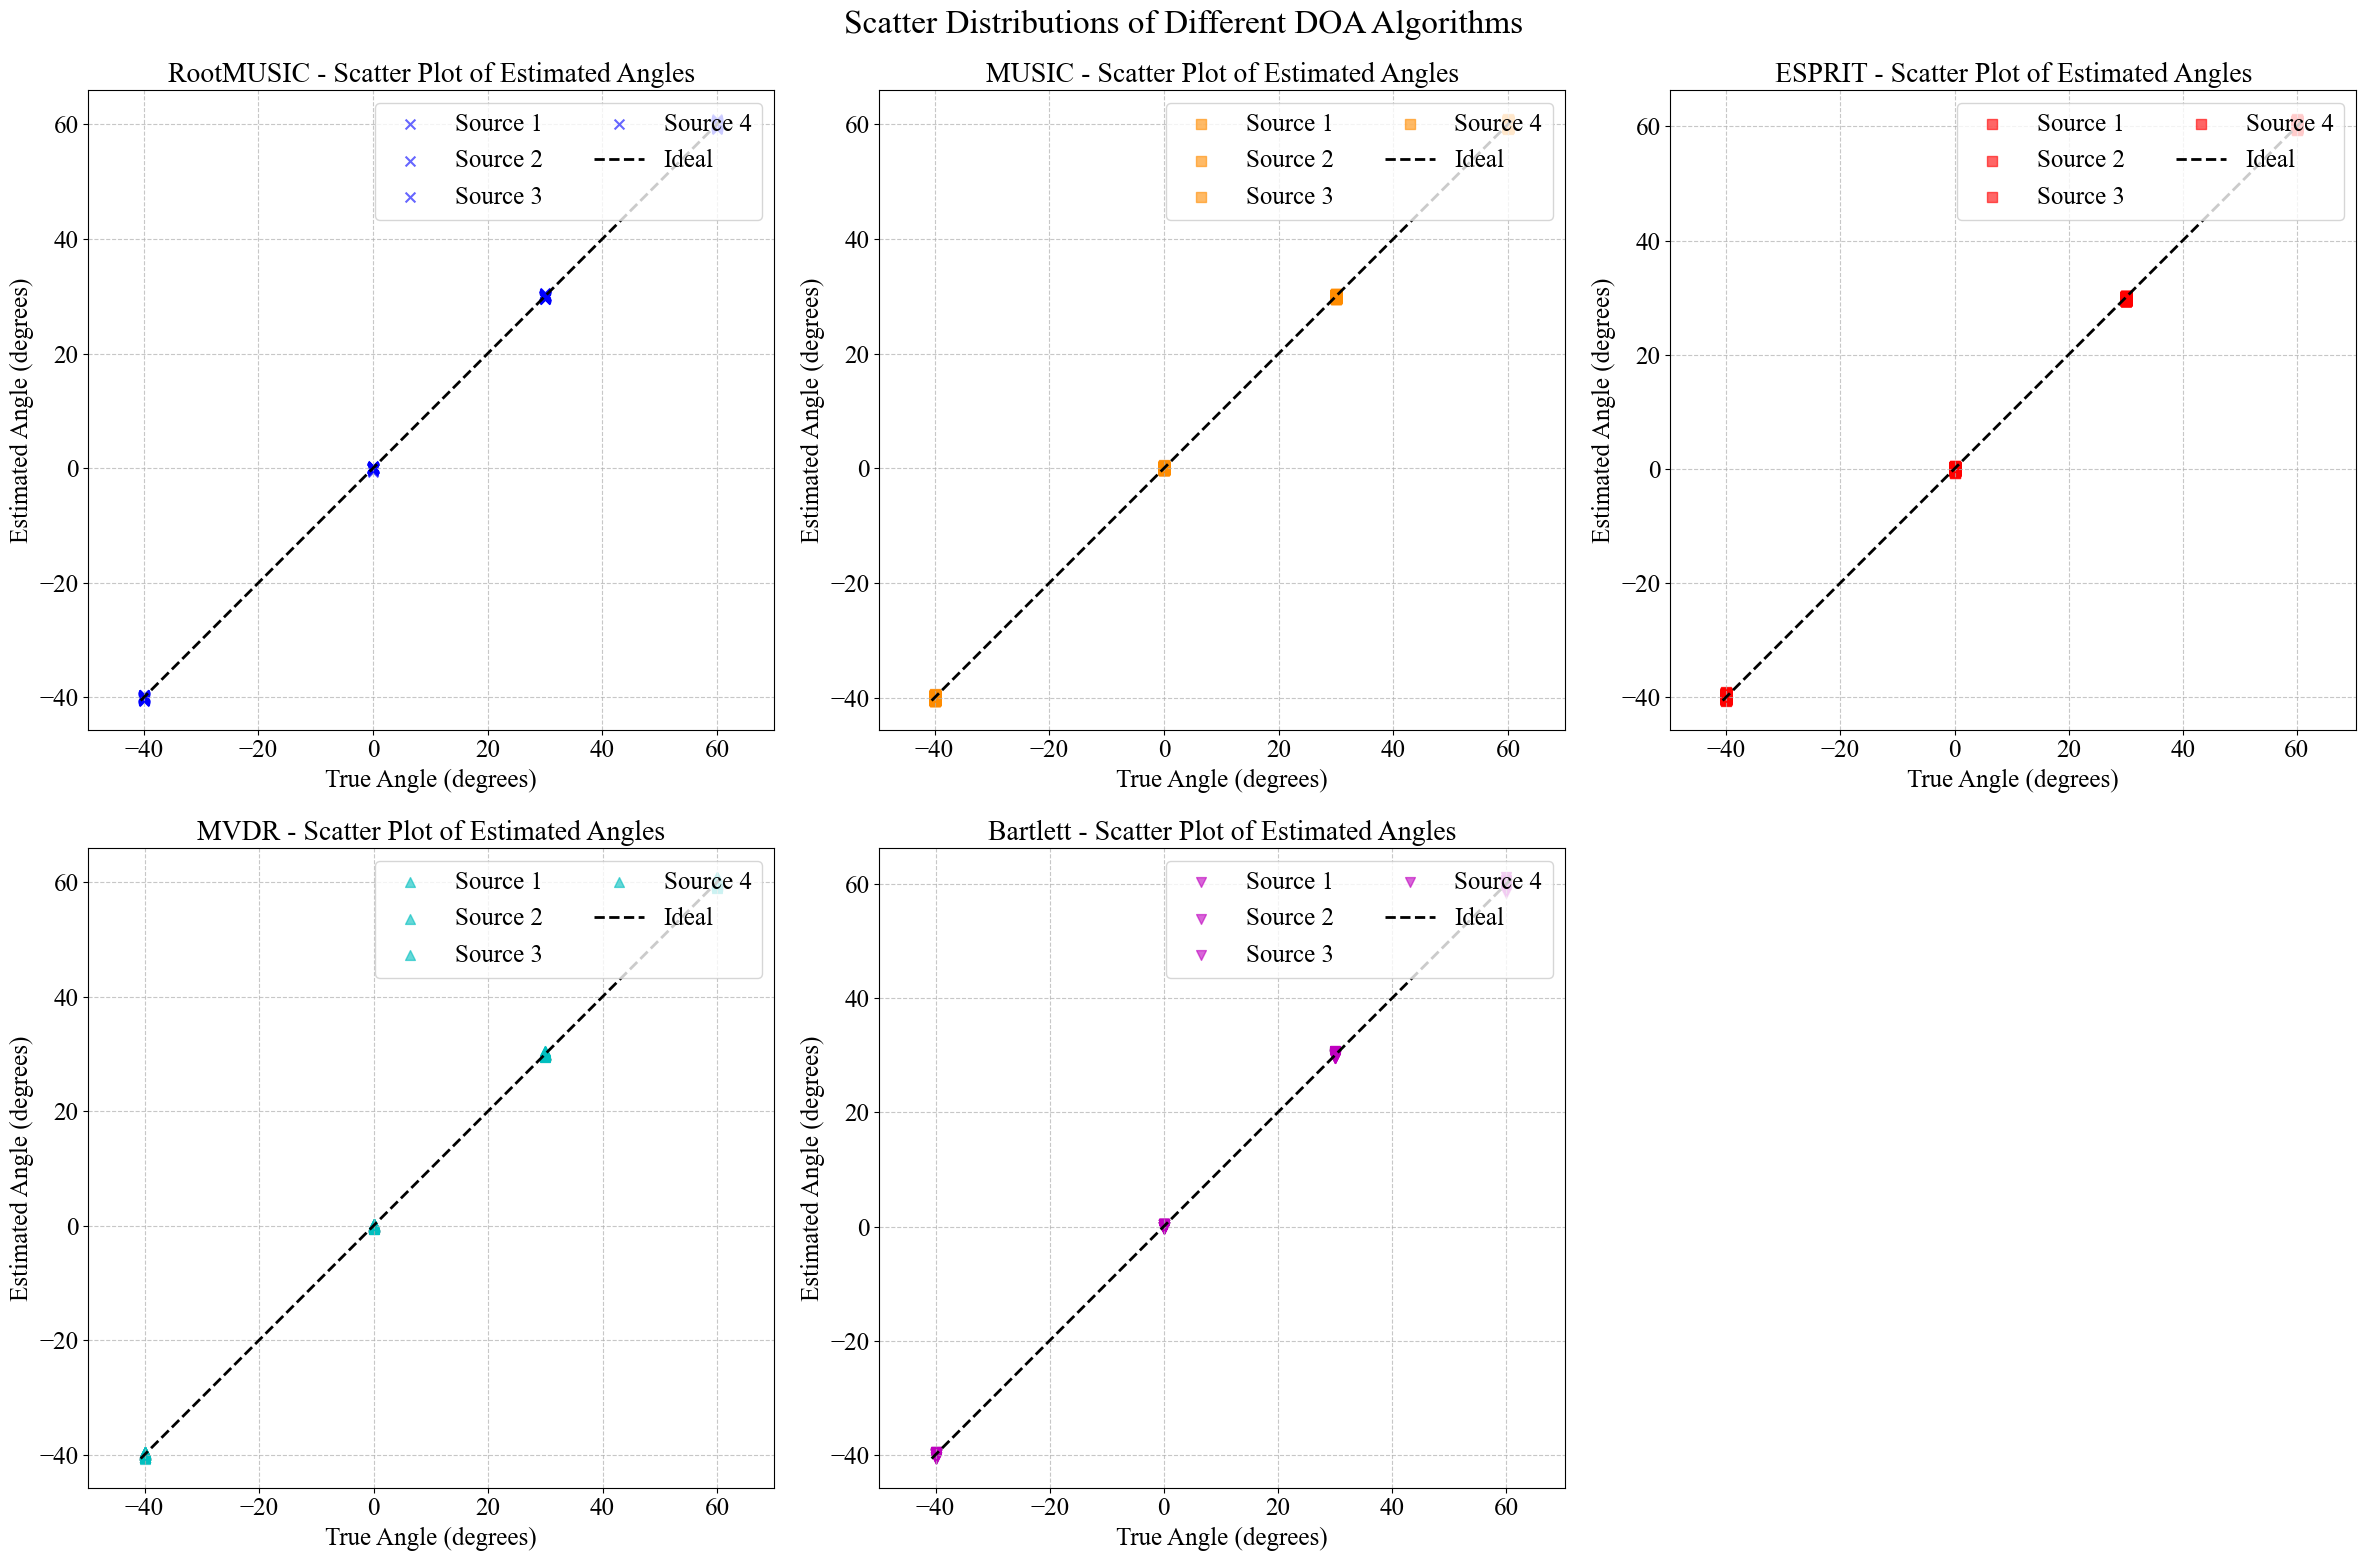

In [11]:
# Plot scatter plot for each algorithm
fig, axes = plt.subplots(2, 3, figsize=(24, 16))
axes = axes.flatten()

for i, (alg_name, estimates) in enumerate(sample_result.sample_estimates.items()):
    ax = axes[i]
    plt_tools.plot_scatter_estimates(
        true_angles=source_angles,
        estimates=estimates,
        algorithm_name=alg_name,
        angle_unit='deg',
        ax=ax
    )
    ax.set_title(f'{alg_name} - Scatter Plot of Estimated Angles', fontsize=20)

# Hide the last unused subplot if there are fewer than 6 algorithms
for j in range(len(sample_result.sample_estimates), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Scatter Distributions of Different DOA Algorithms', fontsize=24, y=0.98)
plt.tight_layout()
plt.show()

## 6. 不同算法的CDF对比

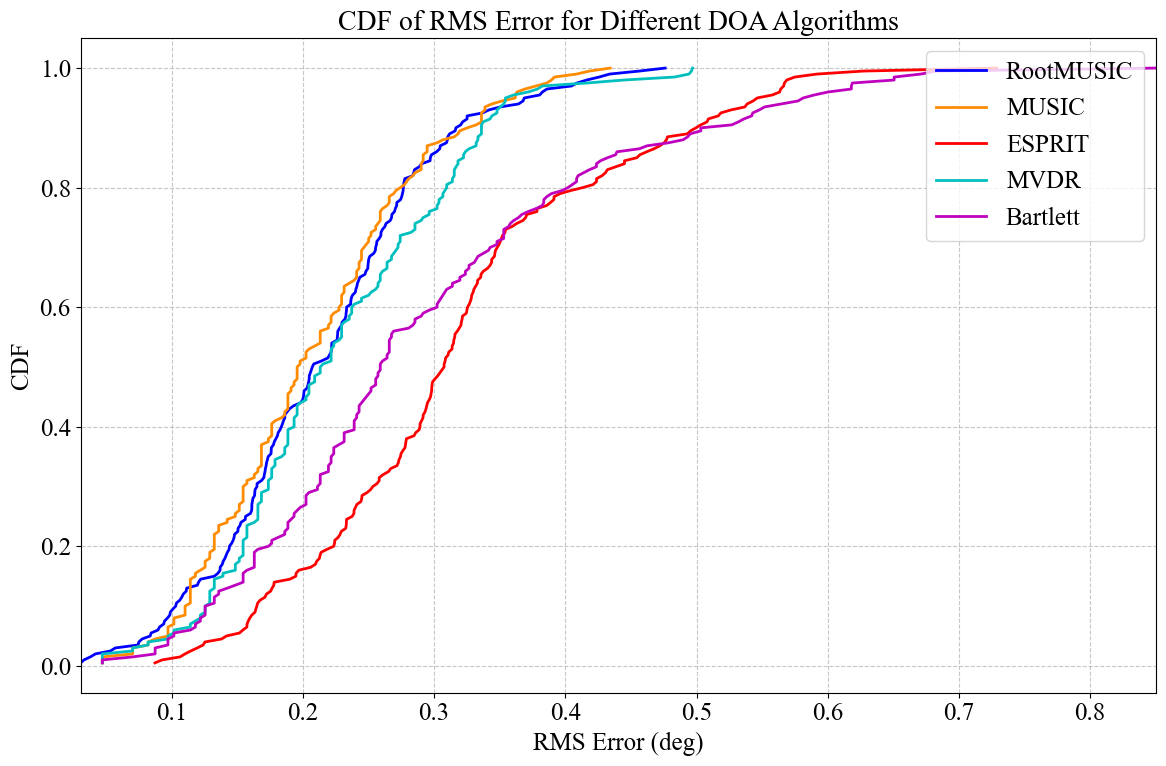

In [12]:
# Plot CDFs of RMS Error Using Enhanced plot_cdf Function
fig, ax = plt.subplots(figsize=(12, 8))
plt_tools.plot_cdf(
    estimates=sample_result.sample_estimates,
    true_angles=source_angles,
    metric_name='RMS Error',
    metric_unit='deg',
    metric_type='rms',
    ax=ax
)
plt.title('CDF of RMS Error for Different DOA Algorithms', fontsize=20)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

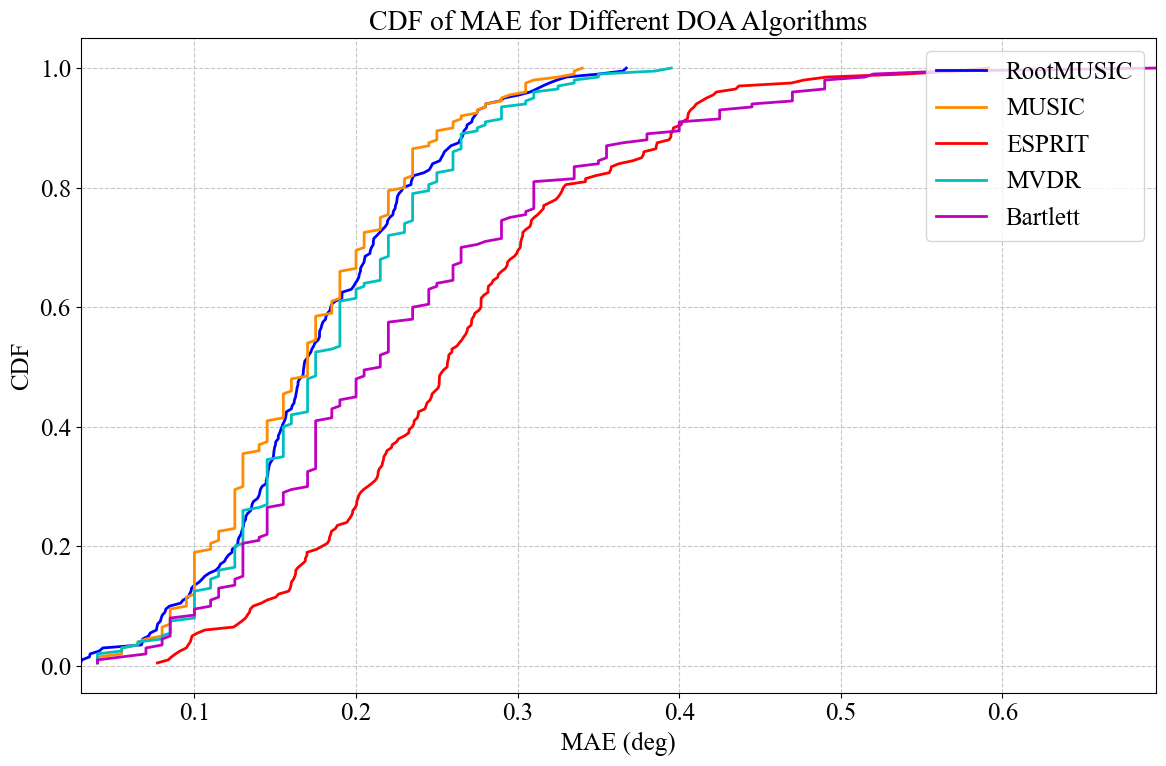

In [13]:
# Plot CDFs of MAE Using Enhanced plot_cdf Function
fig, ax = plt.subplots(figsize=(12, 8))
plt_tools.plot_cdf(
    estimates=sample_result.sample_estimates,
    true_angles=source_angles,
    metric_name='MAE',
    metric_unit='deg',
    metric_type='mae',
    ax=ax
)
plt.title('CDF of MAE for Different DOA Algorithms', fontsize=20)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

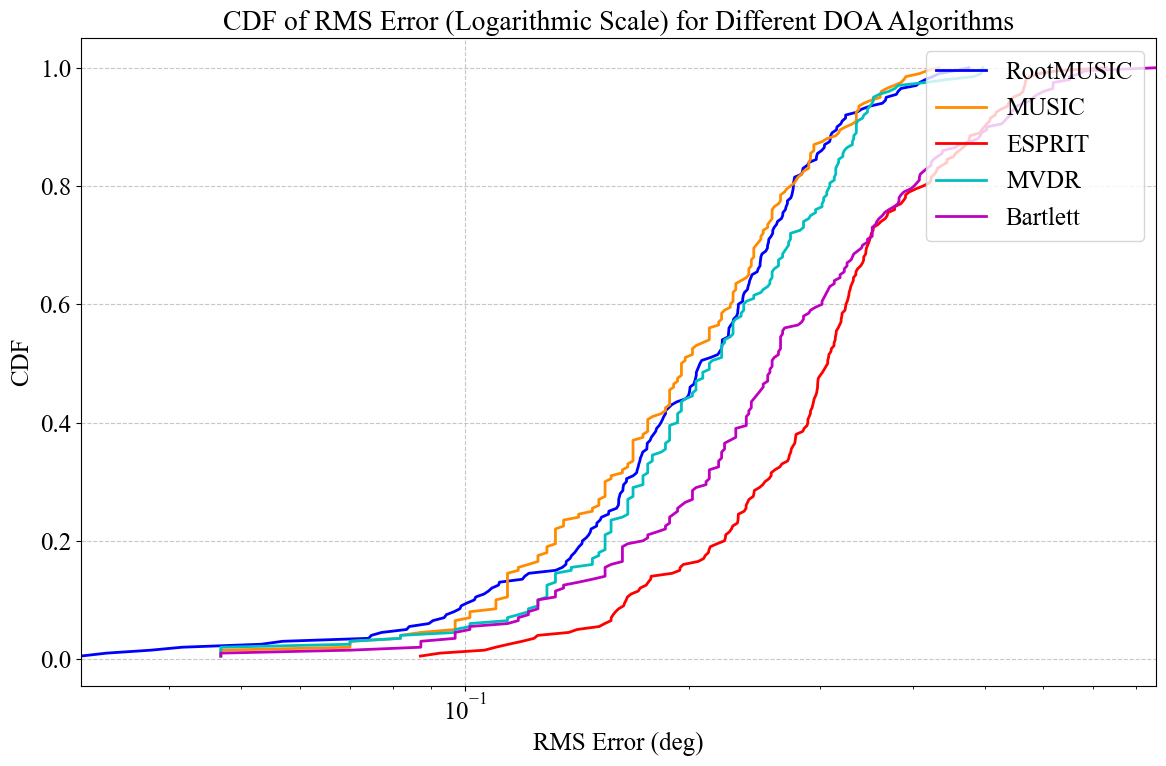

In [14]:
# Plot CDFs with Logarithmic Scale for Detailed Analysis
fig, ax = plt.subplots(figsize=(12, 8))
plt_tools.plot_cdf(
    estimates=sample_result.sample_estimates,
    true_angles=source_angles,
    metric_name='RMS Error',
    metric_unit='deg',
    metric_type='rms',
    ax=ax
)
# Set logarithmic scale on x-axis
ax.set_xscale('log')
plt.title('CDF of RMS Error (Logarithmic Scale) for Different DOA Algorithms', fontsize=20)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

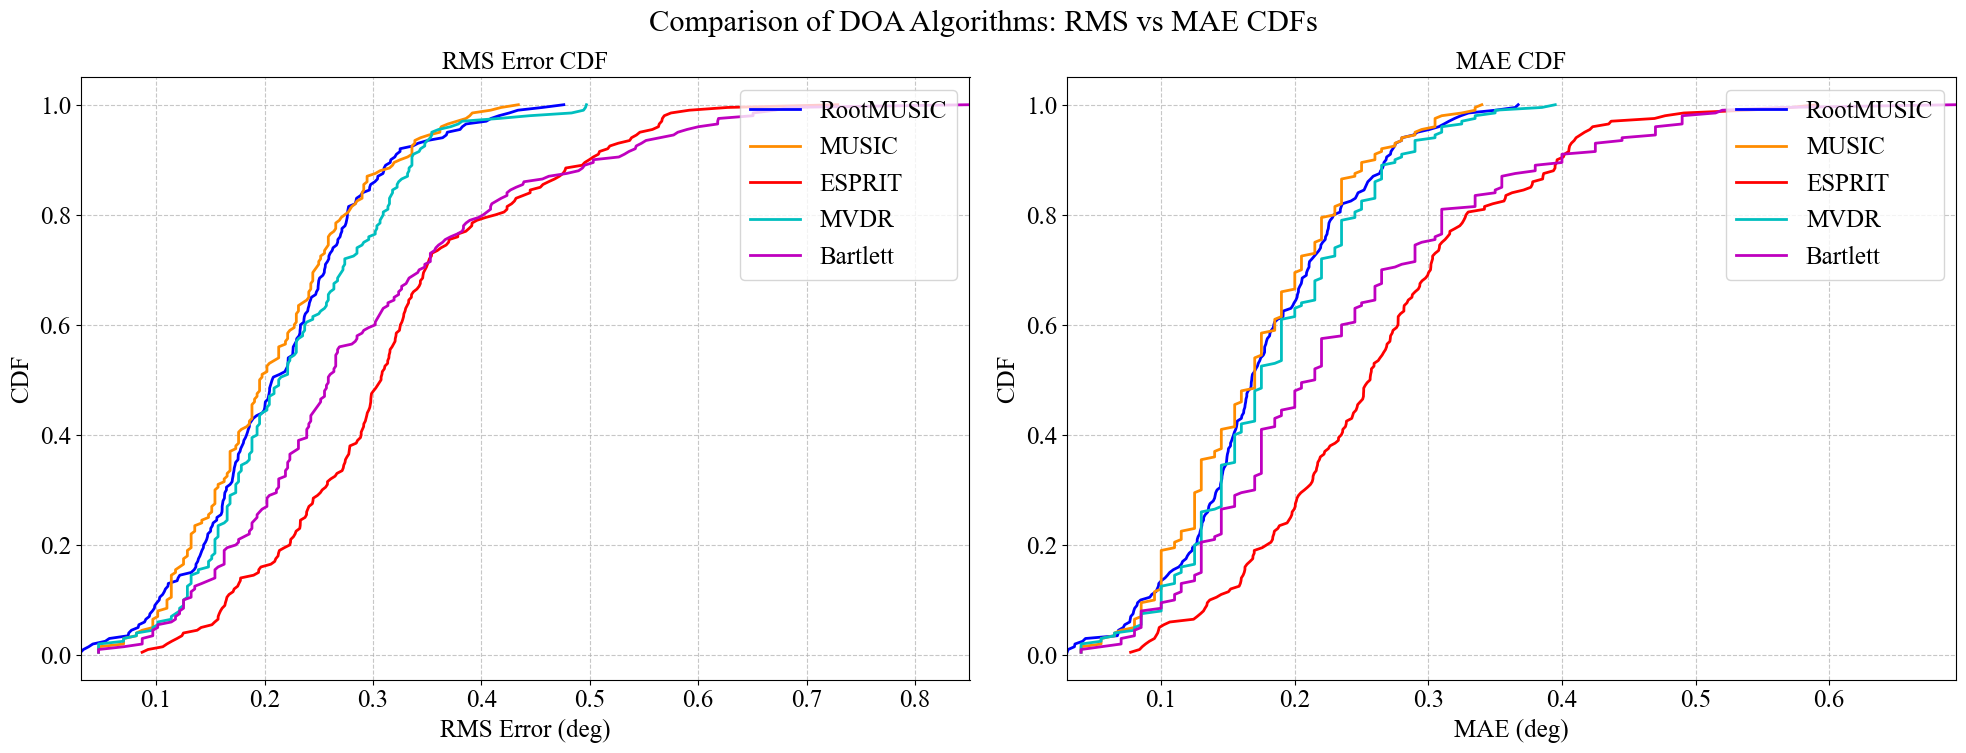

In [15]:
# Create a side-by-side comparison of RMS and MAE CDFs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Plot RMS CDF on the left
plt_tools.plot_cdf(
    estimates=sample_result.sample_estimates,
    true_angles=source_angles,
    metric_name='RMS Error',
    metric_unit='deg',
    metric_type='rms',
    ax=ax1
)
ax1.set_title('RMS Error CDF', fontsize=18)
ax1.grid(True, linestyle='--', alpha=0.7)

# Plot MAE CDF on the right
plt_tools.plot_cdf(
    estimates=sample_result.sample_estimates,
    true_angles=source_angles,
    metric_name='MAE',
    metric_unit='deg',
    metric_type='mae',
    ax=ax2
)
ax2.set_title('MAE CDF', fontsize=18)
ax2.grid(True, linestyle='--', alpha=0.7)

plt.suptitle('Comparison of DOA Algorithms: RMS vs MAE CDFs', fontsize=22, y=0.95)
plt.tight_layout()
plt.show()

## Summary

This notebook demonstrates the use of our custom DOA performance evaluator and plotting tools to analyze the performance of multiple DOA algorithms under different conditions.

### Key Findings:

1. **SNR Performance**: 
   - All algorithms show improved MSE as SNR increases
   - Root-MUSIC and ESPRIT generally perform closest to the CRB
   - Bartlett has the highest MSE across all SNR values
   - Bias decreases with increasing SNR for all algorithms

2. **Snapshot Performance**: 
   - Increasing the number of snapshots improves MSE for all algorithms
   - The improvement is more significant for subspace-based methods (Root-MUSIC, MUSIC, ESPRIT)
   - Root-MUSIC and ESPRIT maintain good performance even with fewer snapshots

3. **Resolution Performance**: 
   - All algorithms show improved MSE as angular separation increases
   - Root-MUSIC and ESPRIT outperform other algorithms for smaller angular separations
   - Bartlett has the lowest resolution capability
   - MUSIC performs well but is computationally more expensive than Root-MUSIC

4. **Scatter Distributions**: 
   - Subspace-based methods (Root-MUSIC, MUSIC, ESPRIT) show tighter scatter distributions
   - Beamforming methods (MVDR, Bartlett) show more spread-out scatter distributions
   - All algorithms show consistent performance across different sources

5. **CDF Comparison**: 
   - Root-MUSIC and ESPRIT generally show the best performance (lowest RMS and MAE) across all CDF percentiles
   - MUSIC performs well but is slightly worse than the subspace methods
   - MVDR shows moderate performance
   - Bartlett has the highest error rates

### Plotting Tools Used:

- `plot_metric_vs_parameter`: For plotting performance metrics against various parameters
- `plot_scatter_estimates`: For visualizing the relationship between true and estimated angles
- `plot_cdf`: For analyzing the distribution of estimation errors

These plotting tools provide a unified and flexible way to visualize DOA performance results, making it easier to compare different algorithms and scenarios.